In [1]:
%load_ext autoreload
%autoreload 2
%aimport load.loader

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from load.loader import ArcadeDataset
from parse.parser import ArcadeParser
from parse.graph_parser import GraphEmbedder

In [3]:
# keys = ["C_Lav_", "C_Lvav_", "C_Lava_", "C_Sav_", "C_Savav_", "CH_Lav_", "CH_Lvav_", "CH_Lava_", "CH_Sav_", "CH_Savav_"]
# keys = ["CH_Lav_", "CH_Lvav_", "CH_Lava_", "CH_Sav_", "CH_Savav_"]
keys = ["CH_Lav_"]

Data from jevarts/encoder/parsed_sims/raw/CH_Lav_graph.csv successfully downloaded
seed:  0


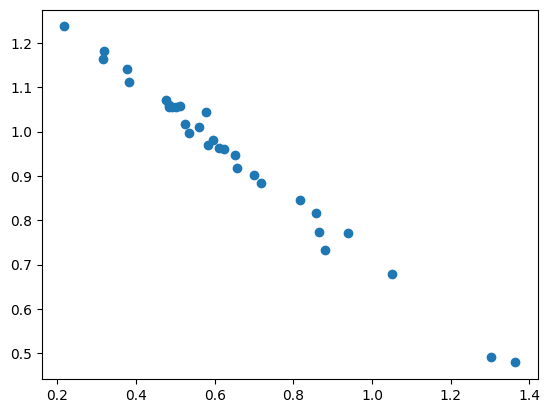

In [21]:
embedder = GraphEmbedder()
embeddings = embedder.embed_graph(keys[0])
plt.scatter(embeddings[:, 0], embeddings[:, 1])
plt.show()

In [ ]:
dataset = ArcadeDataset(keys, split_ratio=0.2)
print(f"{len(dataset)} samples in dataset")

train_subset = dataset.train_subset()
test_subset = dataset.test_subset()

print(f"{len(train_subset)} samples in train subset")
print(f"{len(test_subset)} samples in test subset")

train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=True)

# PCA

In [ ]:
def filter_features_by_seed(seeds, features, labels):
    filtered_features = []
    filtered_labels = []
    
    for feature, label in zip(features, labels):
        if label['seed'] in seeds:
            filtered_features.append(feature)
            filtered_labels.append(label)
    
    return filtered_features, filtered_labels

def filter_features_by_timepoint(timepoints, features, labels):
    filtered_features = []
    filtered_labels = []
    
    for feature, label in zip(features, labels):
        if label['timepoint'] in timepoints:
            filtered_features.append(feature)
            filtered_labels.append(label)
    
    return filtered_features, filtered_labels

In [ ]:
train_features = []
train_labels = []
for X, y in train_loader:
    train_features.append(X[0])
    train_labels.append(y)

# Remove samples with inf
train_features = np.array(train_features)
train_features = train_features[~np.isinf(train_features).any(axis=1)]

timepoints_after_first_day = [(x / 2.0) for x in range(2, 31)]
later_timepoints = [(x / 2.0) for x in range(6, 31)]
train_features, train_labels = filter_features_by_timepoint(later_timepoints, train_features, train_labels)
print(f"{len(train_features)} samples in train features after removing inf")

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)

num_components = 2
pca = PCA(n_components=num_components)
pca.fit(train_features)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Print the top 10 features and their names for each component
for i in range(num_components):
    component = pca.components_[i]
    top_10_features = np.argsort(component)[::-1][:10]
    print(f"Component {i}:")
    for feature_index in top_10_features:
        print(f"{dataset.feature_columns[feature_index]}: {component[feature_index]}")
    print()




In [ ]:
# Plot a test sample in the PCA space
test_features = []
test_labels = []
for X, y in test_loader:
    test_features.append(X[0])
    test_labels.append(y)

test_features = np.array(test_features)
test_labels = np.array(test_labels)
inf_indices = np.isinf(test_features).any(axis=1)
test_features = test_features[~inf_indices]
test_labels = test_labels[~inf_indices]

test_features, test_labels = filter_features_by_timepoint(later_timepoints, test_features, test_labels)

seed_labels = [label['seed'] for label in test_labels]
# test_features, test_labels = filter_features_by_seed([seed_labels[0], seed_labels[1], seed_labels[2]], test_features, test_labels)
timepoint_labels = [label['timepoint'] for label in test_labels]
key_labels = [label['name'] for label in test_labels]
key_dict = {key: i for i, key in enumerate(keys)}
# Convert keys to ints
key_labels = [key_dict[key[0]] for key in key_labels]


print(f"{len(test_features)} samples in test features after removing inf")

test_features = scaler.transform(test_features)

test_features_pca = pca.transform(test_features)

plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=timepoint_labels)
plt.title("PCA (timepoint)")
plt.show()

plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=seed_labels)
plt.title("PCA (seed)")
plt.show()


plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=key_labels)
plt.title("PCA (key)")
plt.show()

In [ ]:
keys = ["CH_Lava_", "CH_Lvav_"]

dataset = ArcadeDataset(keys, split_ratio=0.2)
print(f"{len(dataset)} samples in dataset")

train_subset = dataset.train_subset()
test_subset = dataset.test_subset()

print(f"{len(train_subset)} samples in train subset")
print(f"{len(test_subset)} samples in test subset")

train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=True)


train_features = []
train_labels = []
for X, y in train_loader:
    train_features.append(X[0])
    train_labels.append(y)

# Remove samples with inf
train_features = np.array(train_features)
train_features = train_features[~np.isinf(train_features).any(axis=1)]

timepoints_after_first_day = [(x / 2.0) for x in range(2, 31)]
train_features, train_labels = filter_features_by_timepoint(later_timepoints, train_features, train_labels)
print(f"{len(train_features)} samples in train features after removing inf")

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)

num_components = 2
pca = PCA(n_components=num_components)
pca.fit(train_features)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Plot a test sample in the PCA space
test_features = []
test_labels = []
for X, y in test_loader:
    test_features.append(X[0])
    test_labels.append(y)

test_features = np.array(test_features)
test_labels = np.array(test_labels)
inf_indices = np.isinf(test_features).any(axis=1)
test_features = test_features[~inf_indices]
test_labels = test_labels[~inf_indices]

test_features, test_labels = filter_features_by_timepoint(later_timepoints, test_features, test_labels)

seed_labels = [label['seed'] for label in test_labels]
# test_features, test_labels = filter_features_by_seed([seed_labels[0], seed_labels[1], seed_labels[2]], test_features, test_labels)
timepoint_labels = [label['timepoint'] for label in test_labels]
key_labels = [label['name'] for label in test_labels]
key_dict = {key: i for i, key in enumerate(keys)}
# Convert keys to ints
key_labels = [key_dict[key[0]] for key in key_labels]


print(f"{len(test_features)} samples in test features after removing inf")

test_features = scaler.transform(test_features)

test_features_pca = pca.transform(test_features)

plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=timepoint_labels)
plt.title("PCA (timepoint)")
plt.show()

# plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=seed_labels)
# plt.title("PCA (seed)")
# plt.show()

plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=key_labels)
plt.title("PCA (key)")
plt.show()